# Type A — Futures Challenge Insurance Hedge

**Asset class:** Futures (ES, NQ, etc.)
**Hedge Type:** Insurance hedge through challenge + funded, guaranteeing EV is realised.

**Method split:**
- **Static DD → Cross-firm pair:** Buy 2 challenges at **different** futures prop firms, hedge them
  against each other through both challenge and funded. Revenue = floor(DD / payout_target) payouts
  per pair. Rare for futures (most are trailing DD).
- **Trailing DD → Personal hedge through funded:** Your brokerage account hedges the single prop account.
  Compounding continues through both challenge and funded phases. If funded fails, the hedge recovers
  the full cost stack. **This is the primary method for futures** (almost all are trailing DD).

## EV Formula

**Static DD (cross-firm pair):**
$$\text{EV}_A = \lfloor DD / \text{target} \rfloor \times S \times \text{target} \times \text{split} - 2 \times \text{challenge cost}$$

**Trailing DD (personal hedge):**
$$\text{EV}_A = \text{funded payout} - \text{total cost stack (challenge + funded compounding)}$$

## Futures-Specific Constraints

| Constraint | Impact |
|-----------|--------|
| **Trailing DD** | Hedge costs compound geometrically (worse than static) |
| **Consistency rule** | Forces multi-day hedging → more compounding events |
| **Payout cap** | Caps funded payout → can kill EV even on cheap challenges |
| **Activation fee** | Adds to total cost beyond the challenge fee |

## Important

- **Cross-firm pairing:** MUST be different prop firms. Same-firm = both accounts closed.
- **Most futures challenges are trailing DD** → personal hedge is the primary method.

---

**Reference:** [futures-hedge-model.md](../../directives/Business/futures-hedge-model.md)

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET_PCT  = 0.06    # 6% funded target (futures typically lower than FX)
SPREAD_PER_CONTRACT = 5.00   # $5 round-trip per mini contract
CONSISTENCY_THRESHOLD = 0.20 # 20% default
DEFAULT_LEVERAGE = 20

print("Type A Futures notebook ready.")
print(f"Defaults: funded_target={FUNDED_TARGET_PCT*100:.0f}%, "
      f"spread=${SPREAD_PER_CONTRACT}/contract, "
      f"consistency={CONSISTENCY_THRESHOLD*100:.0f}%")

Type A Futures notebook ready.
Defaults: funded_target=6%, spread=$5.0/contract, consistency=20%


## 1 — Load Futures Challenge Data & Normalise

In [2]:
# Load most recent futures scrape
json_files = glob.glob(os.path.join(DATA_DIR, "propmatch_futures_*.json"))
if not json_files:
    raise FileNotFoundError(
        "No futures data found. Run: python propmatch_scraper.py --action scrape-futures"
    )

latest = max(json_files, key=os.path.getmtime)
print(f"Loading: {os.path.basename(latest)}")

with open(latest, 'r', encoding='utf-8') as f:
    raw = json.load(f)

challenges_raw = raw.get("challenges", raw if isinstance(raw, list) else [])
print(f"Loaded {len(challenges_raw)} raw futures challenges")


# ── Parse helpers ──
def parse_dollar(val):
    if isinstance(val, (int, float)):
        return float(val)
    if not val or val == '-' or str(val).lower() == 'none':
        return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val).replace(',', ''))
    return float(cleaned) if cleaned else 0.0


def parse_pct(val):
    if isinstance(val, (int, float)):
        return float(val) if val > 1 else val * 100
    if not val or val == '-' or str(val).lower() == 'none':
        return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val))
    return float(cleaned) if cleaned else 0.0


def parse_consistency(val):
    if not val or val == '-' or str(val).lower() == 'none':
        return 0.0
    cleaned = re.sub(r'[^\d.]', '', str(val))
    if cleaned:
        pct = float(cleaned)
        return pct / 100.0 if pct > 1 else pct
    return 0.0


def classify_dd_type(val):
    if not val:
        return "trailing"
    v = str(val).lower()
    if "trail" in v:
        return "trailing"
    if "static" in v or "balance" in v:
        return "static"
    return "trailing"


def normalise_challenge(c):
    fee = parse_dollar(c.get('fee_assumed') or c.get('fee_original') or c.get('fee_discounted') or 0)
    activation = parse_dollar(c.get('activation_fee', 0))
    profit_target = parse_dollar(c.get('profit_target', 0))
    # Handle profit_targets as list
    if profit_target == 0 and c.get('profit_targets'):
        targets = c['profit_targets']
        if isinstance(targets, list) and targets:
            profit_target = sum(parse_dollar(t) for t in targets)
    max_loss = parse_dollar(c.get('max_loss') or c.get('max_drawdown_pct', 0))
    account_size = parse_dollar(c.get('account_size', 0))
    split = parse_pct(c.get('profit_split_pct') or c.get('profit_split', 80)) / 100.0
    payout_cap = parse_dollar(c.get('max_payout_amount', 0))
    min_threshold = parse_dollar(c.get('min_payout_threshold', 0))
    dd_type = classify_dd_type(c.get('max_loss_type', ''))

    # Consistency rules
    cr = c.get('consistency_rule', {})
    if isinstance(cr, dict):
        consistency_eval = parse_consistency(cr.get('eval', 'None'))
        consistency_funded = parse_consistency(cr.get('funded', 'None'))
    else:
        consistency_eval = parse_consistency(c.get('consistency_rule_eval', 'None'))
        consistency_funded = parse_consistency(c.get('consistency_rule_funded', 'None'))

    # Max contracts (minis)
    minis = 0
    mc = c.get('max_contract_size', c.get('max_contracts_minis', 0))
    if isinstance(mc, dict):
        minis = int(mc.get('minis', 0) or 0)
    elif isinstance(mc, str):
        nums = re.findall(r'\d+', mc)
        minis = int(nums[0]) if nums else 0
    else:
        minis = int(mc) if mc else 0

    return {
        'firm': c.get('firm', 'Unknown'),
        'account_size': account_size,
        'steps': int(c.get('steps', 1) if c.get('steps') else 1),
        'fee': fee,
        'activation_fee': activation,
        'profit_target': profit_target,
        'max_loss': max_loss,
        'dd_type': dd_type,
        'profit_split': split,
        'max_contracts_minis': minis,
        'payout_cap': payout_cap,
        'min_payout_threshold': min_threshold,
        'consistency_eval': consistency_eval,
        'consistency_funded': consistency_funded,
    }


parsed = [normalise_challenge(c) for c in challenges_raw]
df_raw = pd.DataFrame(parsed)

print(f"Parsed {len(df_raw)} futures challenges")
print(f"\nAccount sizes: {sorted(df_raw['account_size'].unique())}")
print(f"Drawdown types: {df_raw['dd_type'].value_counts().to_dict()}")
print(f"Consistency rules (eval): None={int((df_raw['consistency_eval'] == 0).sum())}, Has rule={int((df_raw['consistency_eval'] > 0).sum())}")
print(f"Payout caps: Uncapped={int((df_raw['payout_cap'] == 0).sum())}, Capped={int((df_raw['payout_cap'] > 0).sum())}")

Loading: propmatch_futures_20260324_231245.json
Loaded 76 raw futures challenges
Parsed 76 futures challenges

Account sizes: [np.float64(25000.0), np.float64(50000.0), np.float64(75000.0), np.float64(100000.0), np.float64(150000.0), np.float64(200000.0), np.float64(300000.0)]
Drawdown types: {'trailing': 76}
Consistency rules (eval): None=34, Has rule=42
Payout caps: Uncapped=10, Capped=66


## 2 — Type A Model: Method-Aware (Futures)

### Static DD — Cross-Firm Pair (rare for futures)

For the rare static DD futures challenge:
- Buy 2 challenges at **different** firms, hedge them against each other
- At funded: both accounts trade opposite directions across firms
- Revenue = floor(DD / payout_target) payouts before the losing side's DD is exhausted
- Cost = 2 x single challenge cost
- **Must be different prop firms** — same-firm pairing gets detected and closed

### Trailing DD — Personal Hedge Through Funded (primary method)

- Personal brokerage account hedges the single prop account
- Costs compound through challenge phases (consistency rule forces multi-day)
- **Compounding continues through funded** — the hedge keeps growing
- If funded fails → hedge recovers the full cost stack
- If funded succeeds → payout minus total cost stack

### The consistency rule constrains the hedge

If no single day can exceed X% of total profit, you need at least ceil(1/X) days.
This sets a floor on compounding events (and therefore cost growth).

In [3]:
def compute_type_a_futures(ch,
                           funded_target_pct=FUNDED_TARGET_PCT,
                           spread_per_contract=SPREAD_PER_CONTRACT,
                           consistency_override=None):
    """
    Type A Futures: Insurance Hedge (method-aware).

    Static DD  -> Cross-firm pair: 2 challenges at different firms, paired at funded.
    Trailing DD -> Personal hedge through funded, compounding continues.
    """
    S       = ch['account_size']
    fee     = ch['fee']
    act_fee = ch['activation_fee']
    target  = ch['profit_target']
    DD      = ch['max_loss']
    split   = ch['profit_split']
    dd_type = ch['dd_type']
    minis   = ch['max_contracts_minis'] or 1
    cap     = ch['payout_cap']
    threshold_eval = ch['consistency_eval']
    steps   = ch['steps']

    if consistency_override is not None:
        threshold_eval = consistency_override

    if S <= 0 or DD <= 0 or target <= 0:
        return None

    # Consistency rule: minimum number of trading days
    min_days = math.ceil(1.0 / threshold_eval) if threshold_eval > 0 else 1
    N = min_days

    # Walk the eval phase(s) — challenge cost stack
    L = fee
    phases = []

    for step in range(steps):
        step_target = target / steps
        daily_move = step_target / N
        L_start = L
        total_spread = 0.0

        if dd_type == 'trailing':
            for day in range(N):
                hedge_loss = daily_move * L / DD
                day_spread = minis * spread_per_contract * 2
                total_spread += day_spread
                L += hedge_loss + day_spread
        else:
            hedge_loss = target * L / DD
            total_spread = minis * spread_per_contract * 2 * N
            L += hedge_loss + total_spread

        phase_cost = L - L_start
        phases.append({
            'phase': step + 1,
            'target': round(step_target, 2),
            'days': N,
            'insured_start': round(L_start, 2),
            'insured_end': round(L, 2),
            'phase_cost': round(phase_cost, 2),
            'spread_cost': round(total_spread, 2),
        })

    single_challenge_cost = L + act_fee

    if dd_type == 'static':
        # CROSS-FIRM PAIR: 2 challenges at different futures firms
        method = "cross-firm-pair"
        total_cost = 2 * single_challenge_cost
        payout_cycles = max(1, int(DD / (S * funded_target_pct))) if S * funded_target_pct > 0 else 1
        raw_payout = S * funded_target_pct * split * payout_cycles
        funded_payout = min(raw_payout, cap * payout_cycles) if cap > 0 else raw_payout

        EV = funded_payout - total_cost
        breakeven_pct = (total_cost / split / S) * 100 if S > 0 and split > 0 else 0

        margin_per_mini = 1000
        capital_required = minis * margin_per_mini * 2

        return {
            'firm': ch['firm'], 'account_size': S,
            'fee': round(fee, 2), 'activation_fee': round(act_fee, 2),
            'steps': steps, 'profit_target': round(target, 2),
            'max_loss': round(DD, 2), 'dd_type': dd_type,
            'method': method,
            'profit_split_pct': round(split * 100, 1),
            'max_contracts': minis, 'payout_cap': round(cap, 2),
            'consistency_eval': round(threshold_eval, 2),
            'min_trading_days': min_days,
            'phases': phases,
            'single_challenge_cost': round(single_challenge_cost, 2),
            'total_cost': round(total_cost, 2),
            'payout_cycles': payout_cycles,
            'funded_payout': round(funded_payout, 2),
            'EV': round(EV, 2),
            'breakeven_pct': round(breakeven_pct, 2),
            'cycles_to_recover': 1,
            'capital_required': round(capital_required, 2),
            'capital_efficiency': round(EV / capital_required, 4) if capital_required > 0 else 0,
        }

    # TRAILING DD: Personal hedge through funded (primary for futures)
    method = "personal-hedge"

    # Continue compounding through funded phase first payout target
    funded_daily = (S * funded_target_pct) / N
    for day in range(N):
        hedge_loss = funded_daily * L / DD
        day_spread = minis * spread_per_contract * 2
        L += hedge_loss + day_spread

    total_cost = L + act_fee

    raw_payout = S * funded_target_pct * split
    funded_payout = min(raw_payout, cap) if cap > 0 else raw_payout

    EV = funded_payout - total_cost
    breakeven_pct = (total_cost / split / S) * 100 if S > 0 and split > 0 else 0

    if cap > 0 and funded_payout > 0:
        cycles_to_recover = math.ceil(total_cost / (cap * split)) if cap * split > 0 else 999
    else:
        cycles_to_recover = 1

    margin_per_mini = 1000
    capital_required = minis * margin_per_mini * 2

    return {
        'firm': ch['firm'], 'account_size': S,
        'fee': round(fee, 2), 'activation_fee': round(act_fee, 2),
        'steps': steps, 'profit_target': round(target, 2),
        'max_loss': round(DD, 2), 'dd_type': dd_type,
        'method': method,
        'profit_split_pct': round(split * 100, 1),
        'max_contracts': minis, 'payout_cap': round(cap, 2),
        'consistency_eval': round(threshold_eval, 2),
        'min_trading_days': min_days,
        'phases': phases,
        'single_challenge_cost': round(single_challenge_cost, 2),
        'total_cost': round(total_cost, 2),
        'payout_cycles': 1,
        'funded_payout': round(funded_payout, 2),
        'EV': round(EV, 2),
        'breakeven_pct': round(breakeven_pct, 2),
        'cycles_to_recover': cycles_to_recover,
        'capital_required': round(capital_required, 2),
        'capital_efficiency': round(EV / capital_required, 4) if capital_required > 0 else 0,
    }


# Run on all parsed challenges
results_a = [compute_type_a_futures(ch) for ch in parsed]
results_a = [r for r in results_a if r is not None]
df_a = pd.DataFrame(results_a)

pos = (df_a['EV'] > 0).sum()
neg = (df_a['EV'] <= 0).sum()
print(f"Positive EV: {pos}/{len(df_a)} challenges")
print(f"Negative EV: {neg}/{len(df_a)} challenges")
print(f"Average EV: ${df_a['EV'].mean():,.2f}")
if pos > 0:
    print(f"Best EV: {df_a.loc[df_a['EV'].idxmax(), 'firm']} -> ${df_a['EV'].max():,.2f}")

print(f"\n-- By Method --")
if 'method' in df_a.columns:
    for m in df_a['method'].unique():
        mask = df_a['method'] == m
        print(f"  {m:18s} ({mask.sum()} ch): avg EV = ${df_a.loc[mask, 'EV'].mean():,.2f}")

✅ Positive EV: 39/58 challenges
❌ Negative EV: 19/58 challenges
📊 Average EV: $355.75
🎯 Best EV: Traders Launch → $7,940.40

── EV by Account Size ──
  $25K (9 ch): avg EV = $268.62
  $50K (15 ch): avg EV = $459.52
  $75K (1 ch): avg EV = $70.79
  $100K (16 ch): avg EV = $316.43
  $150K (14 ch): avg EV = $-284.24
  $200K (2 ch): avg EV = $1,114.00
  $300K (1 ch): avg EV = $7,940.40

── EV by Drawdown Type ──
  trailing   (58 ch): avg EV = $355.75


## 3 — Type A Rankings (Top 30)

In [ ]:
rank_cols = [
    'firm', 'account_size', 'dd_type', 'review_rating', 'review_count', 'review_factor',
    'fee', 'activation_fee', 'steps', 'profit_target', 'max_loss', 'profit_split_pct',
    'consistency_eval', 'payout_cap',
    'total_cost', 'funded_payout', 'funded_payout_review_adj', 'EV', 'EV_review_adj',
    'breakeven_pct', 'cycles_to_recover', 'capital_required', 'capital_efficiency_review_adj',
]

df_a.sort_values('EV_review_adj', ascending=False)[rank_cols].head(30).style.format({
    'review_rating': '{:.1f}',
    'review_count': '{:,.0f}',
    'review_factor': '{:.3f}',
    'fee': '${:,.0f}',
    'activation_fee': '${:,.0f}',
    'profit_target': '${:,.0f}',
    'max_loss': '${:,.0f}',
    'total_cost': '${:,.2f}',
    'funded_payout': '${:,.2f}',
    'funded_payout_review_adj': '${:,.2f}',
    'EV': '${:,.2f}',
    'EV_review_adj': '${:,.2f}',
    'breakeven_pct': '{:.1f}%',
    'capital_required': '${:,.0f}',
    'capital_efficiency_review_adj': '{:.4f}',
    'profit_split_pct': '{:.0f}%',
    'account_size': '${:,}',
    'payout_cap': '${:,.0f}',
    'consistency_eval': '{:.0%}',
}).bar(subset=['EV_review_adj'], color='#5fba7d').set_caption(
    f"Futures Type A Rankings — Top 30 by Review-Adjusted EV (Funded Target: {FUNDED_TARGET_PCT*100:.0f}%)"
)

,firm,account_size,dd_type,fee,activation_fee,steps,profit_target,max_loss,profit_split_pct,consistency_eval,payout_cap,total_cost,funded_payout,EV,breakeven_pct,cycles_to_recover,capital_required,capital_efficiency
57,Traders Launch,"$300,000.0",trailing,$139,$0,1,"$5,000","$2,000",55%,40%,$0,"$1,959.60","$9,900.00","$7,940.40",1.2%,1,"$4,000",1.9851
55,Traders Launch,"$200,000.0",trailing,$74,$0,1,"$3,000","$1,000",55%,40%,$0,"$1,446.35","$6,600.00","$5,153.65",1.3%,1,"$2,000",2.5768
43,Alpha Futures,"$150,000.0",trailing,$239,$149,1,"$9,000","$6,000",70%,50%,"$15,000","$4,161.45","$6,300.00","$2,138.55",4.0%,1,"$30,000",0.0713
42,My Funded Futures,"$150,000.0",trailing,$347,$0,1,"$9,000","$4,500",90%,50%,"$100,000","$6,042.33","$8,100.00","$2,057.67",4.5%,1,"$30,000",0.0686
30,FundedNext Futures,"$100,000.0",trailing,$250,$0,1,"$6,000","$3,000",80%,40%,$0,"$2,845.81","$4,800.00","$1,954.19",3.6%,1,"$10,000",0.1954
32,Topstep,"$100,000.0",trailing,$99,$149,1,"$6,000","$3,000",90%,50%,"$5,000","$3,357.85","$5,000.00","$1,642.15",3.7%,1,"$20,000",0.0821
53,The Trading Pit Futures,"$150,000.0",trailing,$289,$129,1,"$9,000","$4,500",80%,40%,"$500,050","$5,812.21","$7,200.00","$1,387.79",4.8%,1,"$30,000",0.0463
27,Alpha Futures,"$100,000.0",trailing,$159,$149,1,"$6,000","$4,000",70%,50%,"$15,000","$2,822.62","$4,200.00","$1,377.38",4.0%,1,"$20,000",0.0689
16,Topstep,"$50,000.0",trailing,$49,$149,1,"$3,000","$2,000",90%,50%,"$5,000","$1,362.42","$2,700.00","$1,337.58",3.0%,1,"$10,000",0.1338
13,Top One Futures,"$50,000.0",trailing,$105,$149,1,"$3,000","$2,000",90%,0%,"$2,500","$1,182.90","$2,500.00","$1,317.10",2.6%,1,"$6,000",0.2195


## 4 — EV Bar Chart (Top 15 & Bottom 5)

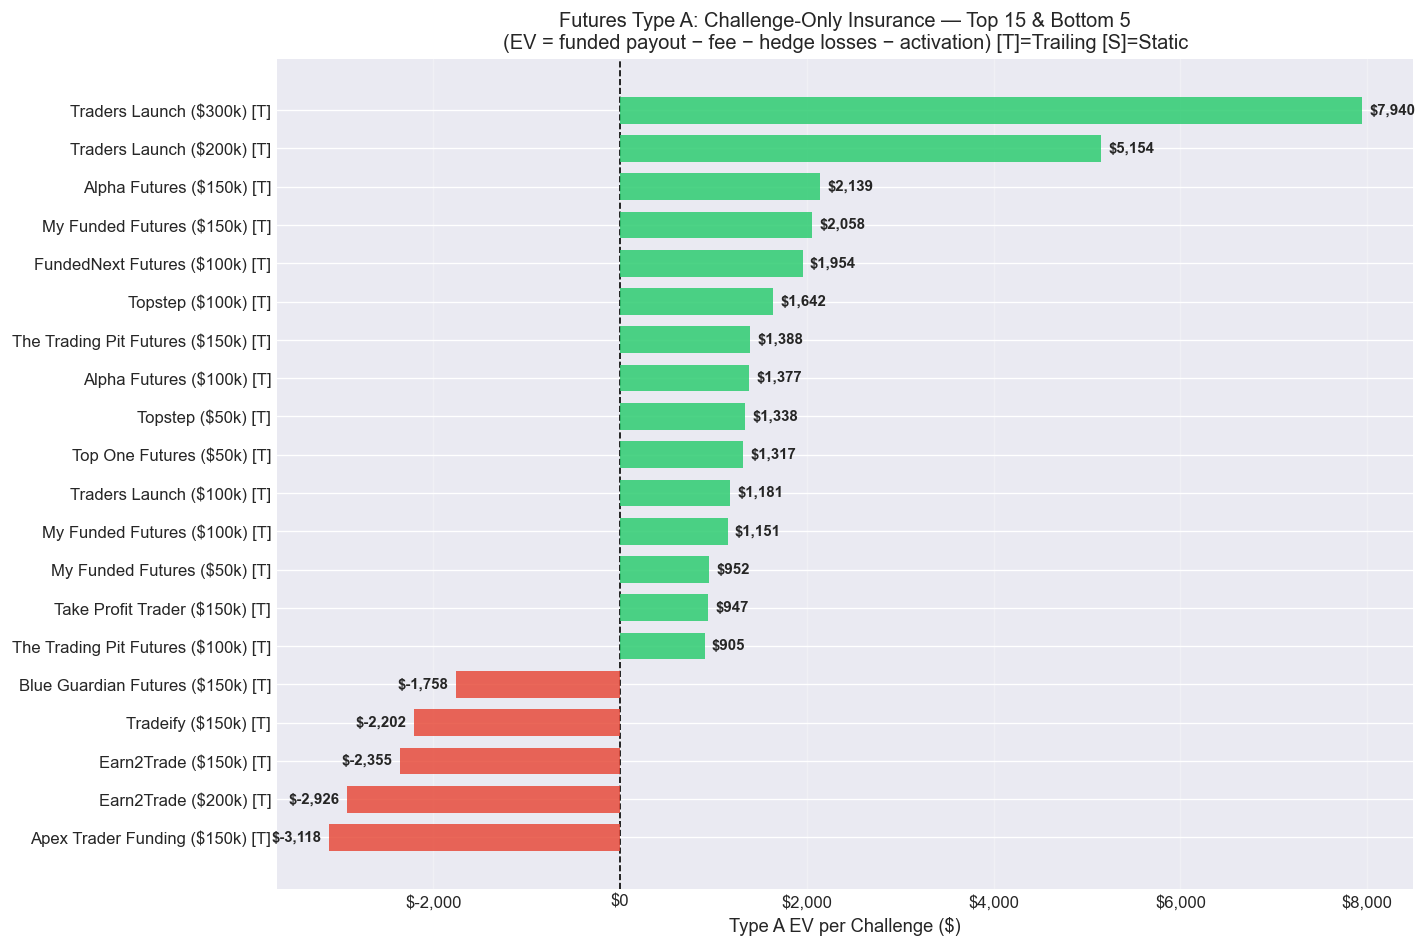

In [5]:
df_sorted = df_a.sort_values('EV', ascending=False)
df_show = pd.concat([df_sorted.head(15), df_sorted.tail(5)]).drop_duplicates(
    subset=['firm', 'account_size']
).sort_values('EV', ascending=True).copy()
df_show['label'] = df_show.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k) [{r['dd_type'][:1].upper()}]", axis=1
)

fig, ax = plt.subplots(figsize=(12, 8))
y = range(len(df_show))
colors = ['#2ecc71' if v > 0 else '#e74c3c' for v in df_show['EV']]
bars = ax.barh(y, df_show['EV'], height=0.7, color=colors, alpha=0.85, zorder=3)

ax.set_yticks(list(y))
ax.set_yticklabels(df_show['label'], fontsize=10)
ax.axvline(x=0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Type A EV per Challenge ($)', fontsize=11)
ax.set_title(f'Futures Type A: Challenge-Only Insurance — Top 15 & Bottom 5\n'
             f'(EV = funded payout − fee − hedge losses − activation) [T]=Trailing [S]=Static',
             fontsize=12)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, df_show['EV']):
    offset = 80 if val >= 0 else -80
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5 — Trailing DD Compounding: Cost Stack Growth

How the insured base grows as the prop account profits day by day.
Each day's hedge loss raises the insured base → raises next day's hedge.

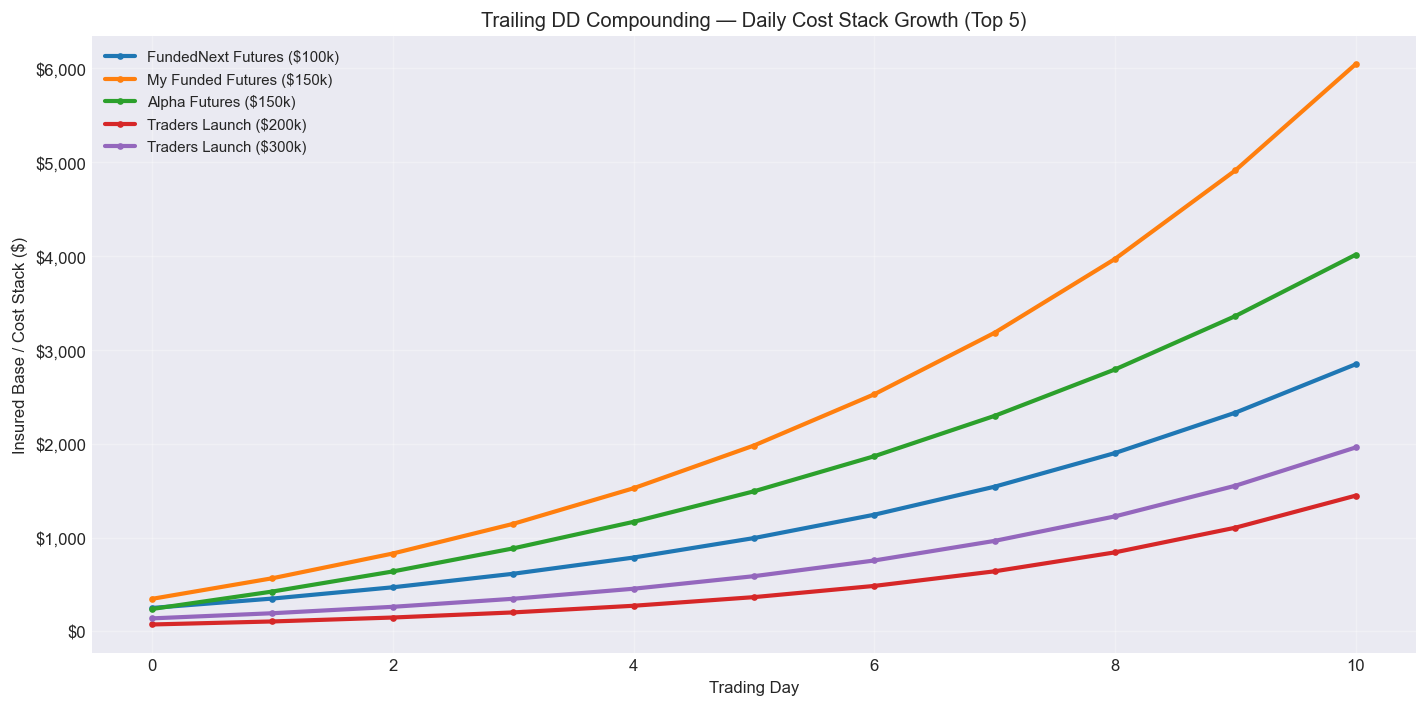

In [6]:
# Top 5 by EV — trace daily insured-base growth
top5 = df_a.nlargest(5, 'EV')
top5_keys = set(zip(top5['firm'], top5['account_size']))
top5_parsed = [ch for ch in parsed if (ch['firm'], ch['account_size']) in top5_keys][:5]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_parsed):
    DD = ch['max_loss']
    target = ch['profit_target']
    fee = ch['fee']
    minis = ch['max_contracts_minis'] or 1
    threshold = ch['consistency_eval']
    min_days = math.ceil(1.0 / threshold) if threshold > 0 else 1
    N = min_days
    daily_move = target / N

    L = fee
    trace = [L]
    for day in range(N):
        hedge_loss = daily_move * L / DD
        spread = minis * SPREAD_PER_CONTRACT * 2
        L += hedge_loss + spread
        trace.append(L)

    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot(range(N + 1), trace, marker='o', markersize=3, linewidth=2.5,
            label=label, color=colors[i % 10])

ax.set_xlabel('Trading Day')
ax.set_ylabel('Insured Base / Cost Stack ($)')
ax.set_title('Trailing DD Compounding — Daily Cost Stack Growth (Top 5)')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 6 — Consistency Rule Impact

What happens to EV as the consistency threshold changes from 10% (strict) to 100% (no rule)?

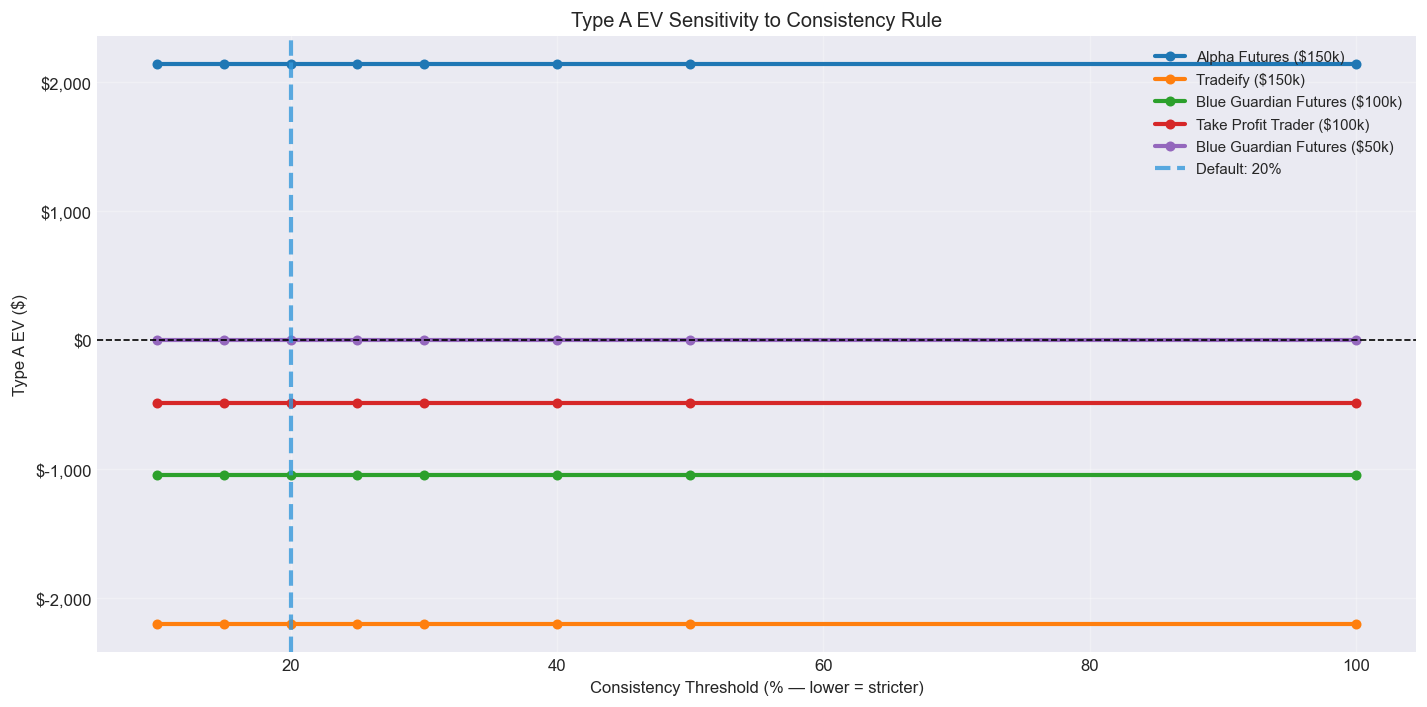

In [7]:
top5_idx = df_a.nlargest(5, 'EV').index.tolist()
top5_ch = [parsed[i] for i in top5_idx]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 1.00]

fig, ax = plt.subplots(figsize=(12, 6))
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_ch):
    evs = []
    for t in thresholds:
        r = compute_type_a_futures(ch, consistency_override=t)
        evs.append(r['EV'] if r else 0)
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot([t * 100 for t in thresholds], evs, marker='o', markersize=5,
            label=label, linewidth=2.5, color=colors[i % 10])

ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.axvline(x=CONSISTENCY_THRESHOLD * 100, color='#3498db', linewidth=2.5,
           linestyle='--', alpha=0.8, label=f'Default: {CONSISTENCY_THRESHOLD*100:.0f}%')
ax.set_xlabel('Consistency Threshold (% — lower = stricter)')
ax.set_ylabel('Type A EV ($)')
ax.set_title('Type A EV Sensitivity to Consistency Rule')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7 — Payout Cap Impact

Many futures firms cap each withdrawal. If the cap is too low, you need multiple
payout cycles just to recover challenge costs — which delays break-even.

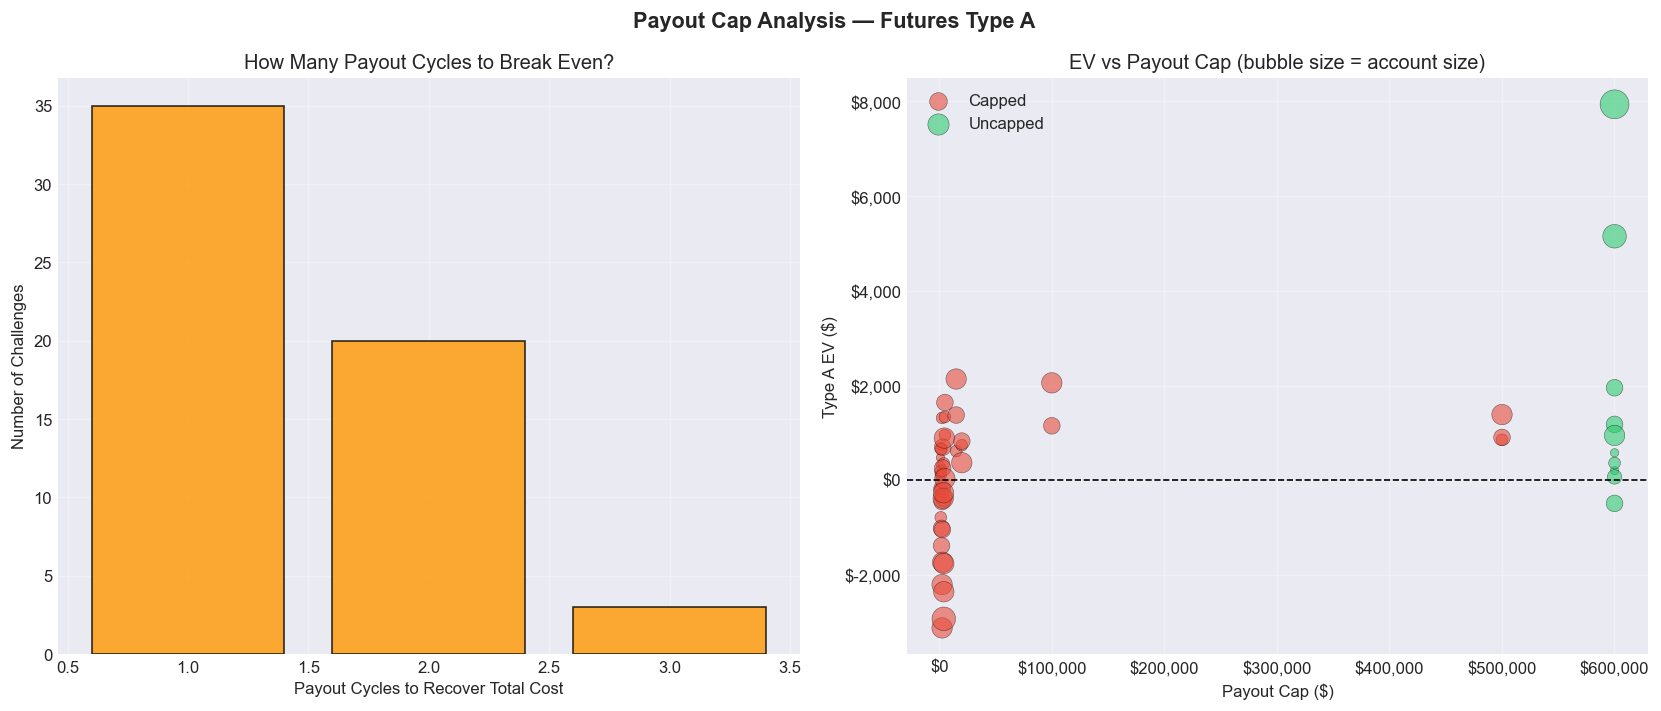

In [8]:
# Scatter: payout cap vs EV, sized by account
df_capped = df_a[df_a['payout_cap'] > 0].copy()
df_uncapped = df_a[df_a['payout_cap'] == 0].copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: bar chart of cycles_to_recover distribution
cycle_counts = df_a['cycles_to_recover'].value_counts().sort_index()
ax1.bar(cycle_counts.index, cycle_counts.values, color='#ff9800', alpha=0.8, edgecolor='black')
ax1.set_xlabel('Payout Cycles to Recover Total Cost')
ax1.set_ylabel('Number of Challenges')
ax1.set_title('How Many Payout Cycles to Break Even?')
ax1.grid(alpha=0.3)

# Right: capped vs uncapped EV
if len(df_capped) > 0:
    ax2.scatter(df_capped['payout_cap'], df_capped['EV'],
               s=df_capped['account_size'] / 1000, alpha=0.6,
               c='#e74c3c', edgecolors='black', linewidth=0.3, label='Capped')
if len(df_uncapped) > 0:
    ax2.scatter([df_a['payout_cap'].max() * 1.2] * len(df_uncapped), df_uncapped['EV'],
               s=df_uncapped['account_size'] / 1000, alpha=0.6,
               c='#2ecc71', edgecolors='black', linewidth=0.3, label='Uncapped')
ax2.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('Payout Cap ($)')
ax2.set_ylabel('Type A EV ($)')
ax2.set_title('EV vs Payout Cap (bubble size = account size)')
ax2.legend()
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle('Payout Cap Analysis — Futures Type A', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 8 — Funded Target Sensitivity

How does EV change as you vary the assumed funded profit target from 2% to 15%?

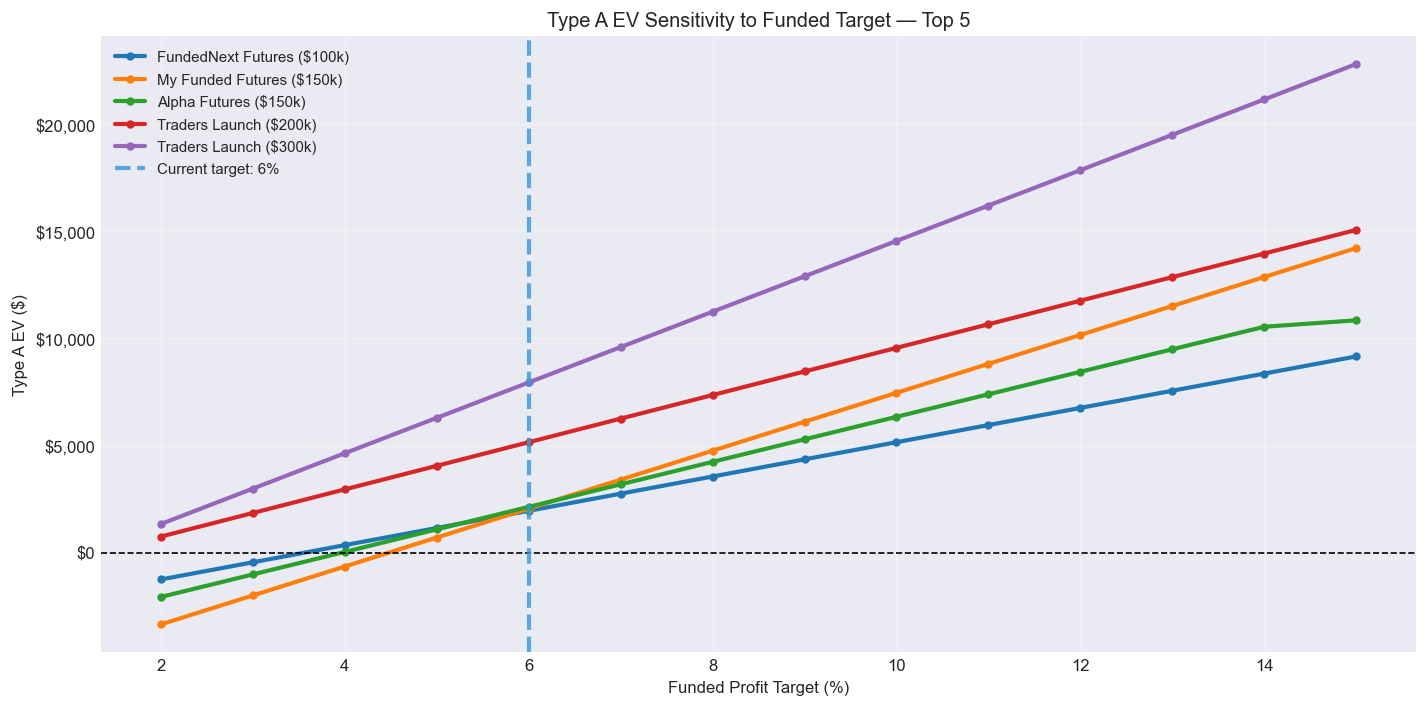

In [9]:
top5 = df_a.nlargest(5, 'EV')[['firm', 'account_size']]
top5_keys = set(zip(top5['firm'], top5['account_size']))
top5_ch = [ch for ch in parsed if (ch['firm'], ch['account_size']) in top5_keys]

fig, ax = plt.subplots(figsize=(12, 6))
target_sweep = [r / 100 for r in range(2, 16)]
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_ch):
    evs = []
    for t in target_sweep:
        r = compute_type_a_futures(ch, funded_target_pct=t)
        evs.append(r['EV'] if r else 0)
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot([t * 100 for t in target_sweep], evs, marker='o', markersize=4,
            label=label, linewidth=2.5, color=colors[i % 10])

ax.axhline(y=0, color='black', linewidth=1, linestyle='--')
ax.axvline(x=FUNDED_TARGET_PCT * 100, color='#3498db', linewidth=2.5, linestyle='--',
           alpha=0.8, label=f'Current target: {FUNDED_TARGET_PCT*100:.0f}%')
ax.set_xlabel('Funded Profit Target (%)')
ax.set_ylabel('Type A EV ($)')
ax.set_title('Type A EV Sensitivity to Funded Target — Top 5')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 9 — Capital Efficiency

Which futures challenges give the most Type A EV per dollar of capital deployed?

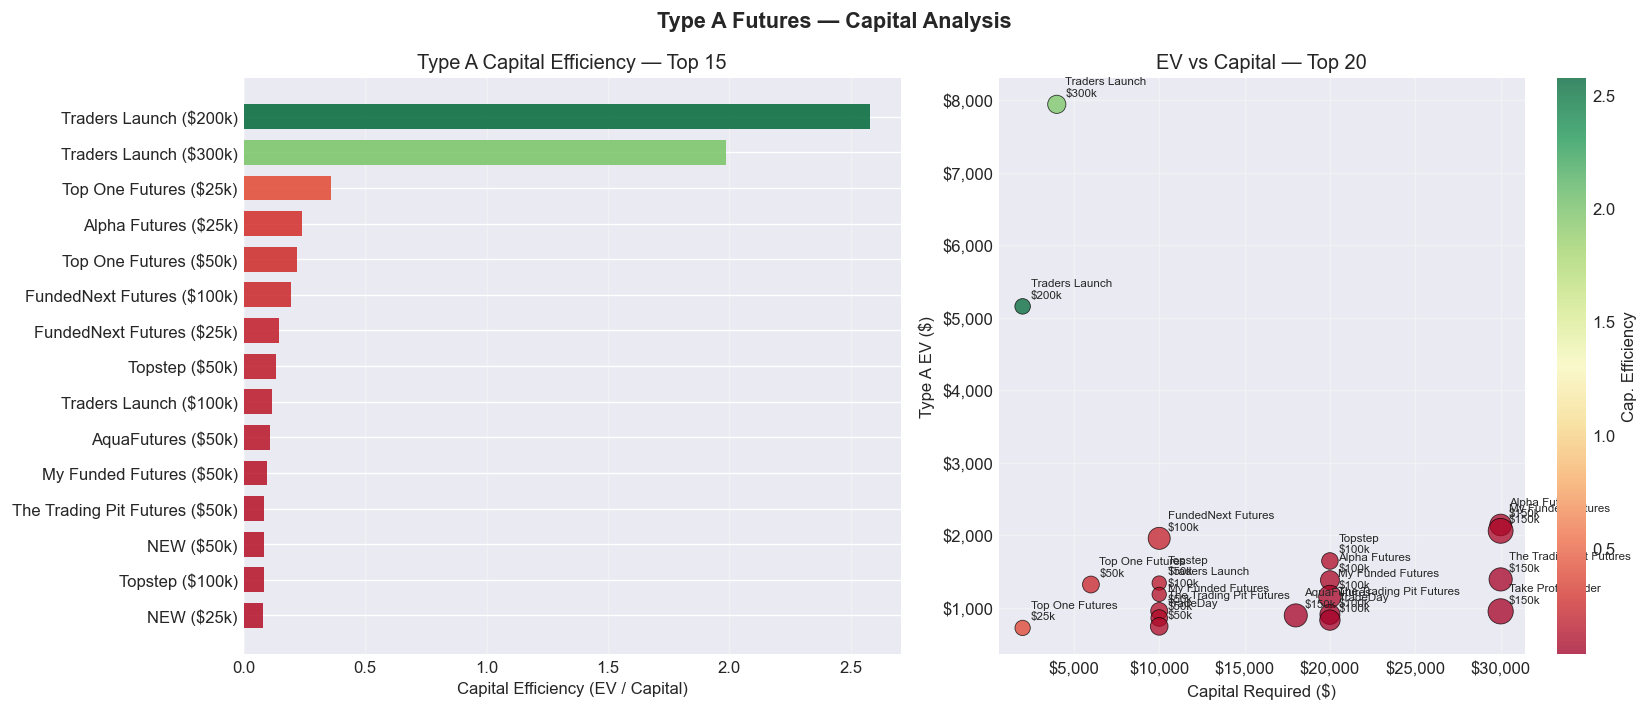

In [10]:
df_cap = df_a[df_a['capital_efficiency'] > 0].nlargest(15, 'capital_efficiency').sort_values(
    'capital_efficiency', ascending=True
).copy()

if len(df_cap) > 0:
    df_cap['label'] = df_cap.apply(
        lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
    )
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    cmap_vals = plt.cm.RdYlGn([v / df_cap['capital_efficiency'].max() for v in df_cap['capital_efficiency']])
    ax1.barh(df_cap['label'], df_cap['capital_efficiency'], color=cmap_vals, alpha=0.85, height=0.7)
    ax1.set_xlabel('Capital Efficiency (EV / Capital)')
    ax1.set_title('Type A Capital Efficiency — Top 15')
    ax1.grid(axis='x', alpha=0.3)
    
    df_sc = df_a[df_a['EV'] > 0].nlargest(20, 'EV')
    if len(df_sc) > 0:
        sc = ax2.scatter(df_sc['capital_required'], df_sc['EV'],
                         s=df_sc['fee'] * 0.5 + 50, alpha=0.75,
                         c=df_sc['capital_efficiency'], cmap='RdYlGn',
                         edgecolors='black', linewidth=0.5)
        for _, row in df_sc.iterrows():
            ax2.annotate(f"{row['firm']}\n${row['account_size']/1000:.0f}k",
                         (row['capital_required'], row['EV']),
                         textcoords='offset points', xytext=(5, 5), fontsize=7)
        ax2.set_xlabel('Capital Required ($)')
        ax2.set_ylabel('Type A EV ($)')
        ax2.set_title('EV vs Capital — Top 20')
        ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
        ax2.grid(alpha=0.3)
        plt.colorbar(sc, ax=ax2, label='Cap. Efficiency')
    
    plt.suptitle('Type A Futures — Capital Analysis', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('No positive-EV challenges for capital analysis.')

## 10 — EV by Account Size

How does EV distribute across different account sizes?

C:\Users\sossi\AppData\Local\Temp\ipykernel_53664\2105635157.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_size, labels=labels, patch_artist=True)


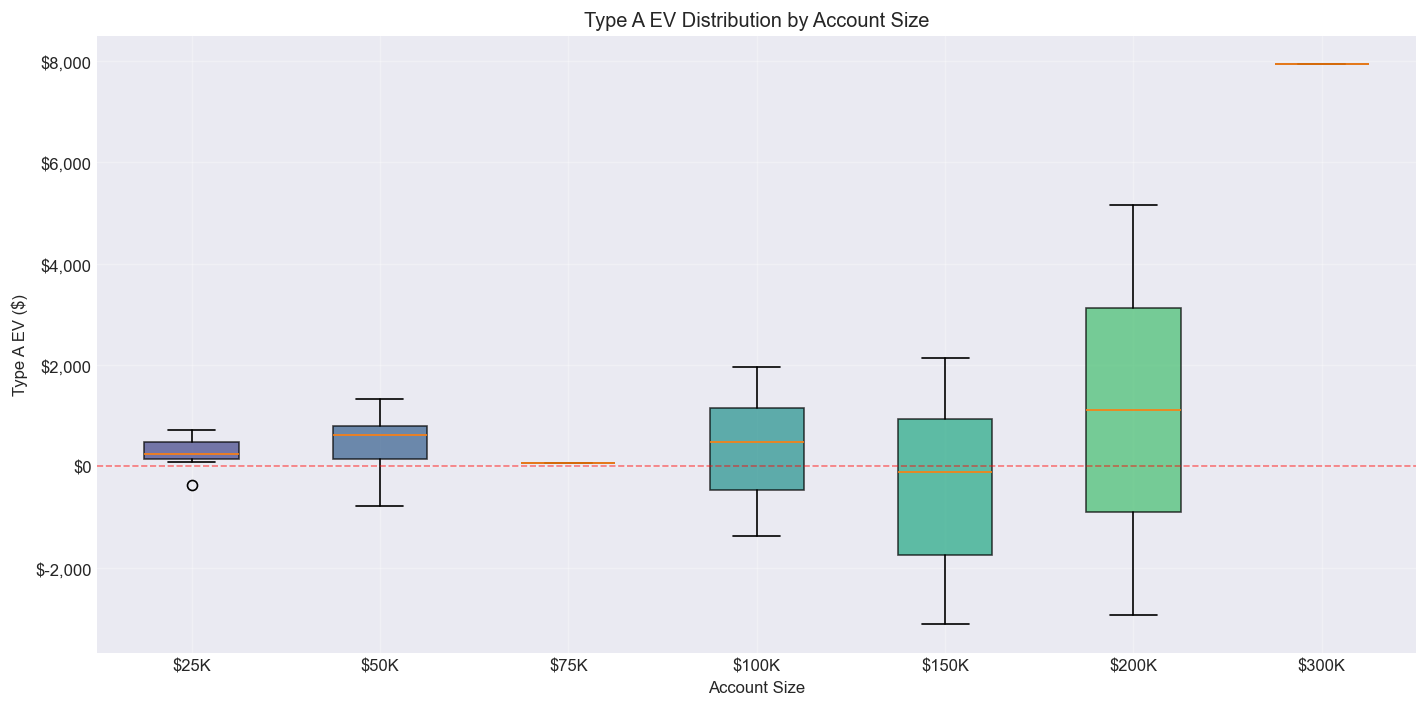

In [11]:
sizes = sorted(df_a['account_size'].unique())
if len(sizes) > 1:
    fig, ax = plt.subplots(figsize=(12, 6))
    data_by_size = [df_a[df_a['account_size'] == s]['EV'].values for s in sizes]
    labels = [f'${s/1000:.0f}K' for s in sizes]
    
    bp = ax.boxplot(data_by_size, labels=labels, patch_artist=True)
    palette = plt.cm.viridis(np.linspace(0.2, 0.8, len(sizes)))
    for patch, color in zip(bp['boxes'], palette):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax.axhline(y=0, color='red', linewidth=1, linestyle='--', alpha=0.5)
    ax.set_xlabel('Account Size')
    ax.set_ylabel('Type A EV ($)')
    ax.set_title('Type A EV Distribution by Account Size')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print(f'Only one account size in data: ${sizes[0]/1000:.0f}K')

## 11 — Type A Futures Summary

### What Type A tells you

- Type A is pure challenge insurance. Hedge stops once funded.
- Trailing DD compounding makes futures challenges more expensive to hedge than FX static-DD.
- Consistency rules force multi-day hedging, increasing compounding events.
- Payout caps can destroy the EV even on cheap challenges.
- Activation fees add dead-weight cost above the challenge fee.

### When to use Type A

- Simplest model — want to know if a single funded payout covers all costs
- Limited capital — only need to fund the challenge hedge, not ongoing
- Screening tool: if a challenge fails Type A, it definitely fails Types B and C

### Limitations

- Challenge costs are 100% sunk if the funded account eventually fails
- No recovery mechanism after funding
- Payout caps may require multiple cycles to break even (not modelled here)

---

**See also:**
- [Type B notebook](type_b_futures_recovery.ipynb) — Funded recovery model
- [Type C notebook](type_c_futures_surplus.ipynb) — Funded surplus model
- [General futures model](futures_hedge_model.ipynb) — All-in-one reference